# SVM - Housing Prices

Objetivo: entrenar un modelo SVM para regresión y evaluar en entrenamiento y prueba.

## 1) Librerias

In [ ]:
!pip install pandas matplotlib seaborn scikit-learn


In [2]:
# Datos
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR


## 2) Cargar datos

In [3]:
# Esto se debe cambiar por la ruta correcta del dataset
# Leer archivo
data = pd.read_csv("housing.csv")


In [4]:
# Vista rapida
data.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:
# Tipos de columnas
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


## 3) Preparar datos

In [6]:
# NOTA: Deben cambiar esto por los que correspondan a su dataset.

variables_a_descartar = []

variables_categoricas = ["CHAS"]
variables_numericas = [
    "CRIM", "ZN", "INDUS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"
]
variables_ordinales = []

# Descartamos variables que no deberian aportar informacion, o que
# al contrario, pueden aportar información pero tienen muchos valores únicos,
# lo que dificulta su uso directo en modelos de machine learning.
variable_dependiente = "MEDV"

In [7]:
for var in variables_categoricas:
    data[var] = data[var].astype("category")

In [8]:
# Deben elegir uno de estos caminos

# Eliminar faltantes clave (si es que hay)
# datos_modelo = data.dropna(subset=["RM", "LSTAT"])

# Imputar faltantes (si es que hay)
# data["RM"] = data["RM"].fillna(data["RM"].median())

In [9]:
# Resumen
data.describe(include="all")


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.0,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
unique,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,471.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,3.613524,11.363636,11.136779,NaN,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,NaN,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,NaN,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,NaN,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,NaN,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,NaN,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000


In [10]:
X = data.drop([variable_dependiente] + variables_a_descartar, axis=1)
y = data[variable_dependiente]


In [11]:
y.head()


0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: MEDV, dtype: float64

In [12]:
# En regresión, la variable dependiente debe ser numérica.
# Si su variable objetivo viniera como texto, conviértanla antes de entrenar.
# Por ejemplo:
# y = pd.to_numeric(y, errors="coerce")

## 4) Separar entrenamiento y prueba (80/20)

In [13]:
random_state = 42 # Esta semilla asegura que los resultados sean reproducibles

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state
)

## 5) Variables para SVM (numéricas + estandarización)

In [15]:
# Este modelo usa support vector regression con kernel radial.
# https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html
# Hiperparametros a ajustar: C, epsilon, kernel, gamma.
modelo = SVR(kernel="rbf", C=10, epsilon=0.1)

# 1) Este es un ejemplo de pipeline que incluye imputación de valores faltantes,
# escalado de variables numéricas y codificación de variables categóricas.
#
# 2) Los pipelines permiten encadenar varios pasos de preprocesamiento y modelado,
# lo que facilita la gestión del flujo de trabajo y reduce el riesgo de errores.
#
# 3) Se pueden combinar con ColumnTransformers para aplicar diferentes transformaciones a
# diferentes tipos de variables (numéricas, categóricas, ordinales, etc.).
pipeline = Pipeline([
    ("preprocesamiento", ColumnTransformer([
        ("numerico", Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler()),
        ]), variables_numericas),
        ("categorico", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(drop="first", sparse_output=False)),
        ]), variables_categoricas)
    ])),
    ("modelo", modelo)
])

## 6) Entrenar y predecir

In [16]:
# Ajustar modelo
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerico', ...), ('categorico', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [17]:
# Prediccion entrenamiento
y_train_pred = pipeline.predict(X_train)

In [18]:
# Prediccion prueba
y_test_pred = pipeline.predict(X_test)

In [19]:
# Comparacion rapida en prueba
pd.DataFrame({
    "Real": y_test.values,
    "Predicho": y_test_pred,
    "Residuo": y_test.values - y_test_pred
}).head()

,Real,Predicho,Residuo
0,23.6,25.156016,-1.556016
1,32.4,30.832220,1.567780
2,13.6,16.040461,-2.440461
3,22.8,22.324592,0.475408
4,16.1,16.361823,-0.261823


## 7) Evaluacion

In [20]:
# Métricas entrenamiento
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = root_mean_squared_error(y_train, y_train_pred)
train_mape = mean_absolute_percentage_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"MAE entrenamiento: {train_mae:.4f}")
print(f"MSE entrenamiento: {train_mse:.4f}")
print(f"RMSE entrenamiento: {train_rmse:.4f}")
print(f"MAPE entrenamiento: {train_mape:.4f}")
print(f"R² entrenamiento: {train_r2:.4f}")

MAE entrenamiento: 1.5749
MSE entrenamiento: 8.3695
RMSE entrenamiento: 2.8930
MAPE entrenamiento: 0.0728
R² entrenamiento: 0.9037


In [21]:
# Métricas prueba
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"MAE prueba: {test_mae:.4f}")
print(f"MSE prueba: {test_mse:.4f}")
print(f"RMSE prueba: {test_rmse:.4f}")
print(f"R² prueba: {test_r2:.4f}")
print(f"MAPE prueba: {test_mape:.4f}")

MAE prueba: 2.1078
MSE prueba: 11.8419
RMSE prueba: 3.4412
R² prueba: 0.8385
MAPE prueba: 0.1155


In [22]:
# Resumen de métricas
pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba"],
    "MAE": [train_mae, test_mae],
    "MSE": [train_mse, test_mse],
    "RMSE": [train_rmse, test_rmse],
    "R2": [train_r2, test_r2],
    "MAPE": [train_mape, test_mape]
})

,Conjunto,MAE,MSE,RMSE,R2,MAPE
0,Entrenamiento,1.574900,8.369528,2.893014,0.903658,0.072826
1,Prueba,2.107833,11.841851,3.441199,0.838521,0.115489


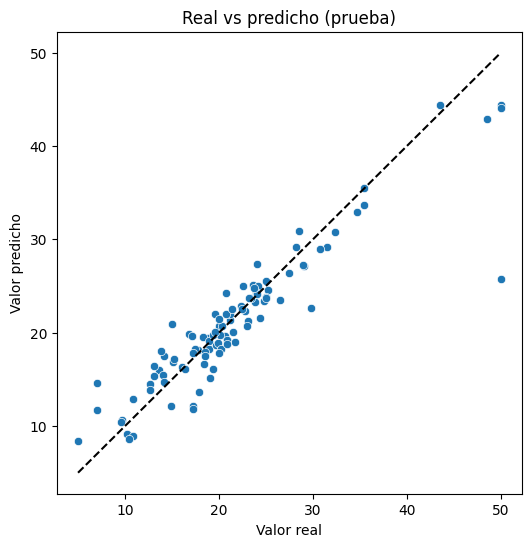

In [23]:
# Valores reales vs predichos en prueba
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_test_pred)
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Real vs predicho (prueba)")
limites = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
plt.plot(limites, limites, linestyle="--", color="black")
plt.show()

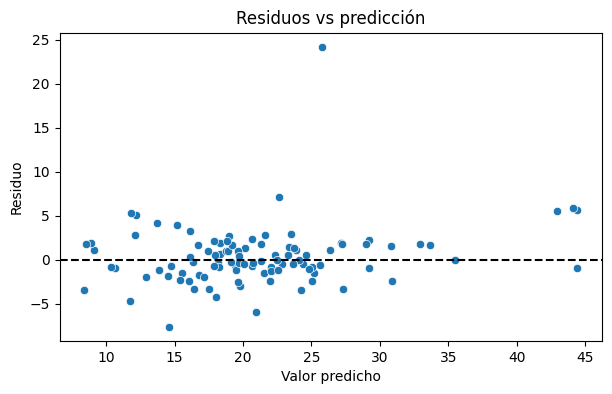

In [24]:
# Residuos en prueba
residuos = y_test - y_test_pred

plt.figure(figsize=(7, 4))
sns.scatterplot(x=y_test_pred, y=residuos)
plt.axhline(0, linestyle="--", color="black")
plt.xlabel("Valor predicho")
plt.ylabel("Residuo")
plt.title("Residuos vs predicción")
plt.show()